<a href="https://colab.research.google.com/github/Optimized-Brain/Quantum-Percolation-Using-Cirq/blob/main/QuantumPercolationUsingCirq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Update package resources to account for version changes.
import importlib, pkg_resources
importlib.reload(pkg_resources)

<module 'pkg_resources' from '/usr/local/lib/python3.10/dist-packages/pkg_resources/__init__.py'>

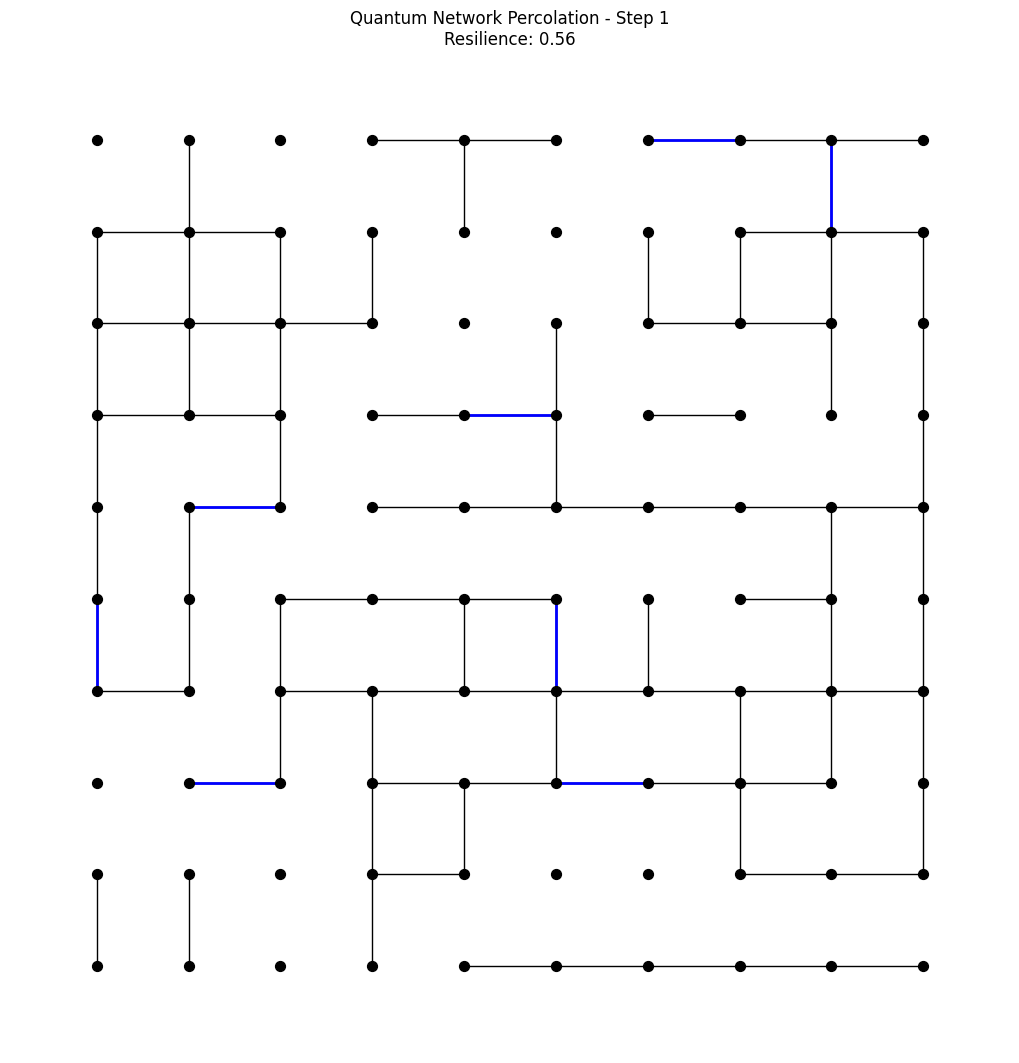

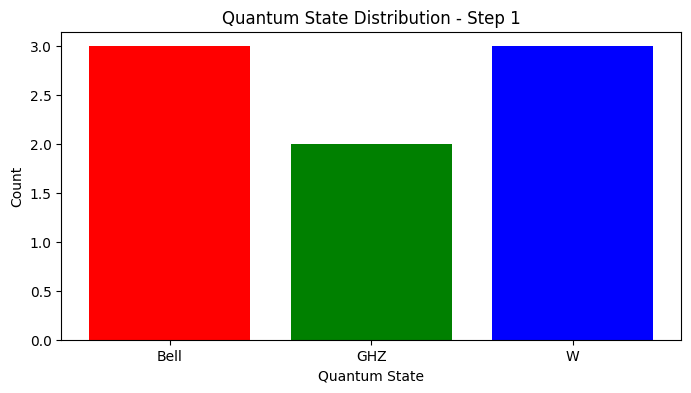

Step 1:
Number of entangled pairs: 8
Average fidelity of entangled pairs: 0.86
Network resilience: 0.56
Quantum state distribution: {'Bell': 3, 'GHZ': 2, 'W': 3}
----------------------------------------


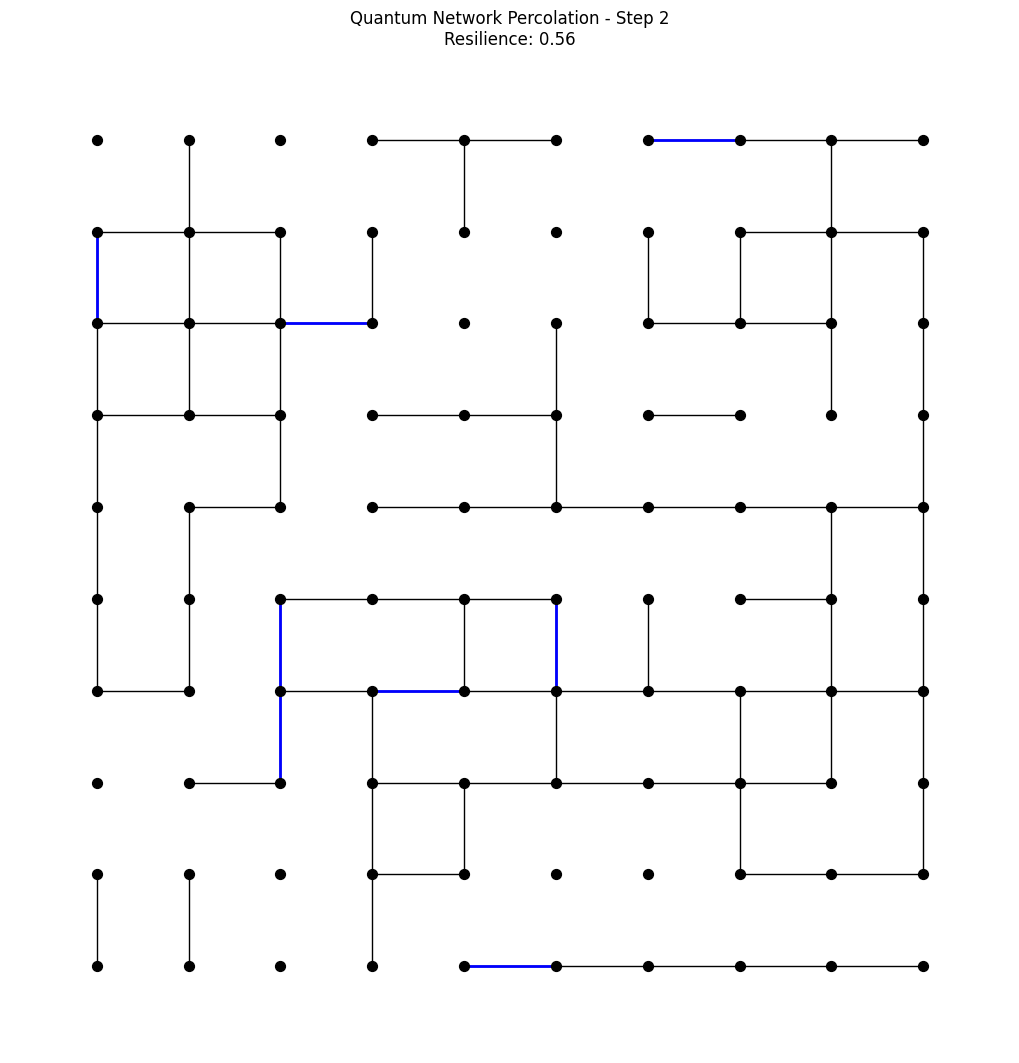

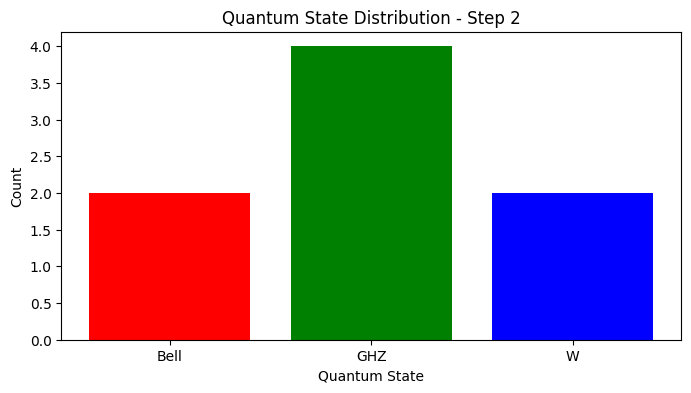

Step 2:
Number of entangled pairs: 8
Average fidelity of entangled pairs: 0.90
Network resilience: 0.56
Quantum state distribution: {'Bell': 2, 'GHZ': 4, 'W': 2}
----------------------------------------


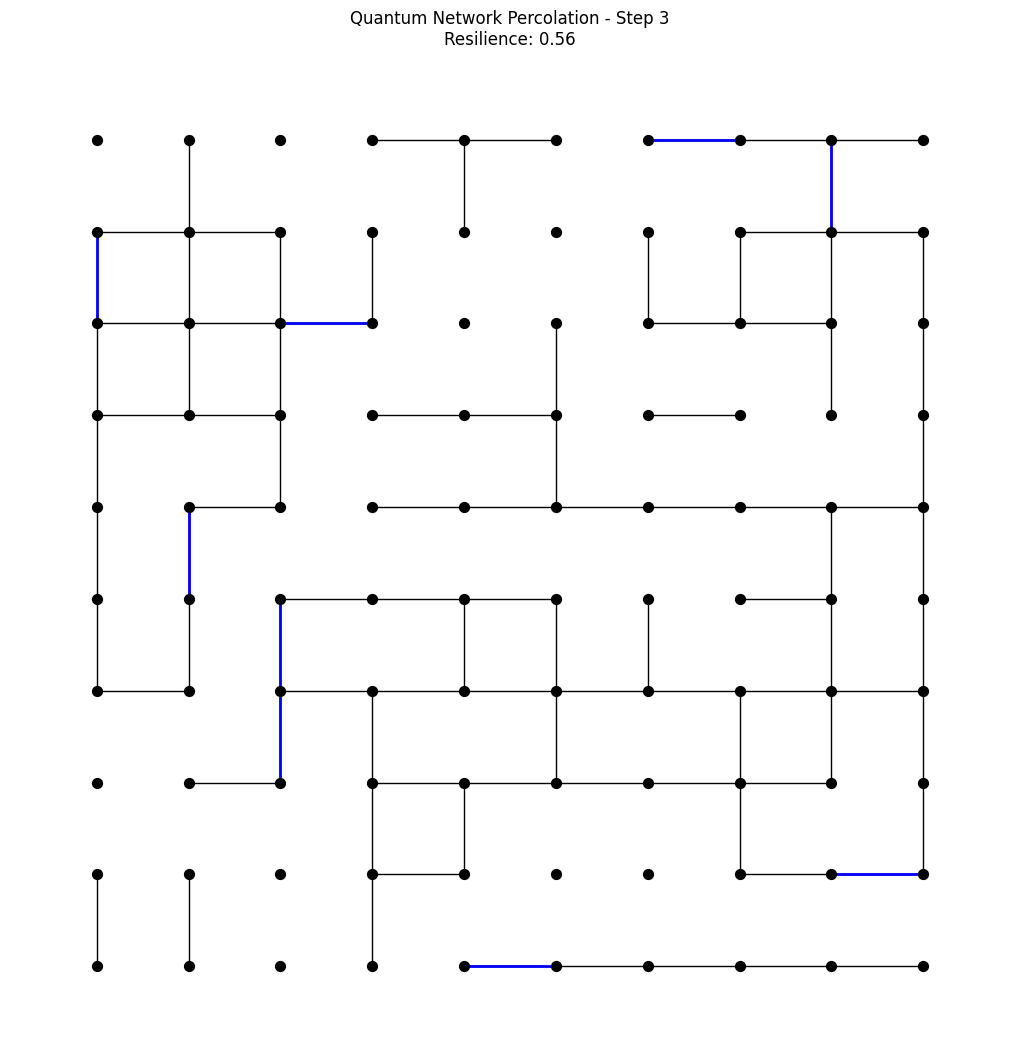

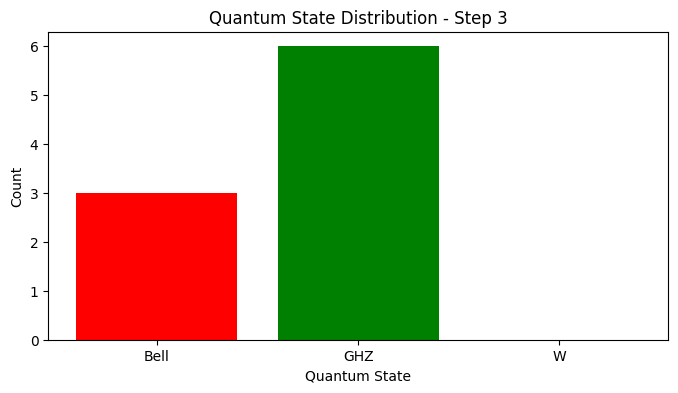

Step 3:
Number of entangled pairs: 9
Average fidelity of entangled pairs: 0.89
Network resilience: 0.56
Quantum state distribution: {'Bell': 3, 'GHZ': 6, 'W': 0}
----------------------------------------


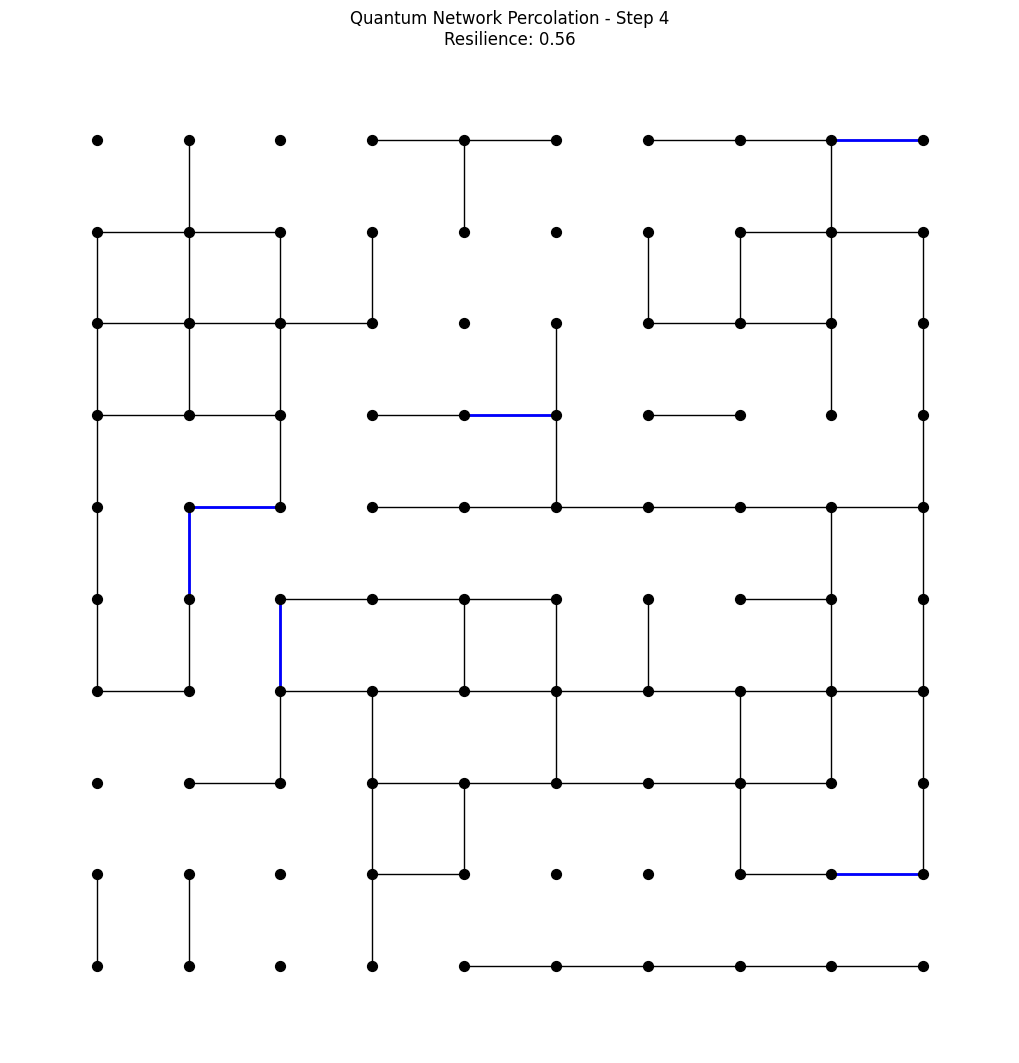

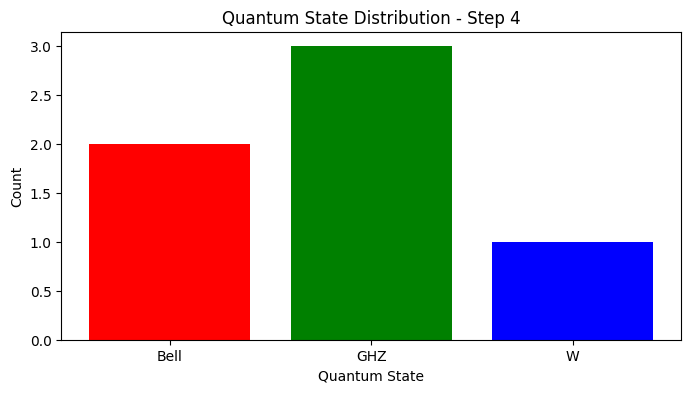

Step 4:
Number of entangled pairs: 6
Average fidelity of entangled pairs: 0.86
Network resilience: 0.56
Quantum state distribution: {'Bell': 2, 'GHZ': 3, 'W': 1}
----------------------------------------


In [ ]:
import tensorflow as tf
import tensorflow_quantum as tfq
import cirq
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

class QuantumNetwork:
    def __init__(self, n, p):
        self.n = n
        self.p = p
        self.network = nx.grid_2d_graph(n, n)
        self.initialize_edges()

    def initialize_edges(self):
        for (u, v) in self.network.edges():
            if np.random.rand() > self.p:
                self.network.remove_edge(u, v)
            else:
                self.network[u][v]['weight'] = np.random.rand()  # Assign random weights
                self.network[u][v]['fidelity'] = np.random.rand()  # Assign random fidelity
                self.network[u][v]['type'] = np.random.choice(['Bell', 'GHZ', 'W'])  # Random quantum state type

    def create_quantum_circuit(self, edge_type):
        qubits = [cirq.GridQubit(0, 0), cirq.GridQubit(0, 1)]
        circuit = cirq.Circuit()
        if edge_type == 'Bell':
            circuit.append([cirq.H(qubits[0]), cirq.CNOT(qubits[0], qubits[1])])
        elif edge_type == 'GHZ':
            circuit.append([cirq.H(qubits[0]), cirq.CNOT(qubits[0], qubits[1]), cirq.CNOT(qubits[1], cirq.GridQubit(0, 2))])
        elif edge_type == 'W':
            circuit.append([cirq.X(qubits[0]), cirq.H(qubits[1]), cirq.CNOT(qubits[1], qubits[0])])
        return circuit

    def simulate_entanglement(self):
        entangled_pairs = []
        for (u, v) in self.network.edges():
            if np.random.rand() < self.p:
                entangled_pairs.append((u, v))
        return entangled_pairs

    def apply_error_correction(self, entangled_pairs):
        corrected_pairs = []
        for (u, v) in entangled_pairs:
            if self.network[u][v]['fidelity'] > 0.8:  # Example threshold for error correction
                corrected_pairs.append((u, v))
        return corrected_pairs

    def add_quantum_repeaters(self):
        for (u, v) in self.network.edges():
            if np.random.rand() < 0.1:  # Example probability of adding a repeater
                self.network.add_edge(u, v, repeater=True)

    def apply_decoherence(self):
        for (u, v) in self.network.edges():
            self.network[u][v]['fidelity'] *= 0.99  # Example decoherence factor

    def update_probabilities(self, step):
        # Example: Decrease probability over time
        self.p = max(0.1, self.p - 0.01 * step)

    def calculate_resilience(self):
        largest_component = max(nx.connected_components(self.network), key=len)
        resilience = len(largest_component) / (self.n * self.n)
        return resilience

    def simulate(self, steps):
        all_entangled_pairs = []
        resilience_metrics = []
        state_distributions = []
        for step in range(steps):
            self.update_probabilities(step)
            self.apply_decoherence()
            entangled_pairs = self.simulate_entanglement()
            entangled_pairs = self.apply_error_correction(entangled_pairs)
            self.add_quantum_repeaters()
            all_entangled_pairs.append(entangled_pairs)
            resilience = self.calculate_resilience()
            resilience_metrics.append(resilience)
            state_counts = {'Bell': 0, 'GHZ': 0, 'W': 0}
            for (u, v) in entangled_pairs:
                state_counts[self.network[u][v]['type']] += 1
            state_distributions.append(state_counts)
        return all_entangled_pairs, resilience_metrics, state_distributions

    def plot_network(self, all_entangled_pairs, resilience_metrics, state_distributions):
        pos = dict((n, n) for n in self.network.nodes())
        for step, (entangled_pairs, resilience, state_counts) in enumerate(zip(all_entangled_pairs, resilience_metrics, state_distributions)):
            plt.figure(figsize=(10, 10))
            nx.draw(self.network, pos, with_labels=False, node_size=50, node_color='black')
            nx.draw_networkx_edges(self.network, pos, edgelist=entangled_pairs, edge_color='blue', width=2)
            plt.title(f'Quantum Network Percolation - Step {step + 1}\nResilience: {resilience:.2f}')
            plt.show()

            # Plot quantum state distribution
            plt.figure(figsize=(8, 4))
            plt.bar(state_counts.keys(), state_counts.values(), color=['red', 'green', 'blue'])
            plt.title(f'Quantum State Distribution - Step {step + 1}')
            plt.xlabel('Quantum State')
            plt.ylabel('Count')
            plt.show()

            # Additional details
            num_entangled = len(entangled_pairs)
            avg_fidelity = np.mean([self.network[u][v]['fidelity'] for (u, v) in entangled_pairs])
            print(f"Step {step + 1}:")
            print(f"Number of entangled pairs: {num_entangled}")
            print(f"Average fidelity of entangled pairs: {avg_fidelity:.2f}")
            print(f"Network resilience: {resilience:.2f}")
            print(f"Quantum state distribution: {state_counts}")
            print("-" * 40)

# Parameters
n = 10  # Grid size
p = 0.5  # Initial probability of edge being entangled
steps = 4  # Number of simulation steps

# Simulate quantum network
qn = QuantumNetwork(n, p)
all_entangled_pairs, resilience_metrics, state_distributions = qn.simulate(steps)
qn.plot_network(all_entangled_pairs, resilience_metrics, state_distributions)
